In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
os.chdir('/home/nazanin/github/dt-inspired-neuro-fuzzy')

In [3]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch.nn as nn
from model.litanfis import LitAnfis, SklearnLitAnfisWrapper
from model.unfis import UNFIS
from model.GIFT import GIFT, SklearnGIFTWrapper
from model.anfis import ANFIS, SklearnAnfisWrapper
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

In [4]:
# config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_size = 105
batch_size = 32
random_state = 199

lr = 0.005
max_lr = 0.01
epochs = 100

alpha = 1.0
min_alpha = 0.0

learning_params = dict(train_size=train_size,
                       batch_size=batch_size,
                       random_state=random_state,
                       lr=lr,
                       max_lr=max_lr,
                       epochs=epochs,
                       alpha=alpha,
                       min_alpha=min_alpha)

/home/nazanin/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [5]:
from tests.uci_test import Wine, Haberman, Cryotheraphy, Heart, Thyroid, Autism, Immunotherapy, Iris, Glass, Segmentaition
from tests.class_test import Digits, Segmentation, Digits_UCI, Diabetes, BCW, DNA, Smoke
from torch.utils.data import DataLoader


experiment = Heart(session_id=random_state)
train_dataset = experiment.train_dataset(device)
test_dataset = experiment.test_dataset(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

learning_params['train_size'] = experiment.train_numpy()[0].shape[0]

KeyboardInterrupt: 

False

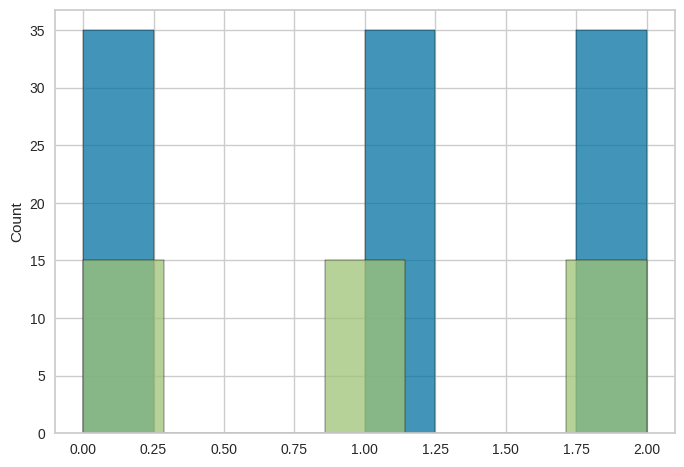

In [ ]:
sns.histplot(experiment.train_numpy()[1])
sns.histplot(experiment.test_numpy()[1])

binary = len(np.unique(experiment.train_numpy()[1])) == 2
binary

In [ ]:
# prepare the model

from train.early_stop import EarlyStopping

model_params = {
    'type': "gift", # anfis, unfis, gift, litanfis
    'in_features': experiment.train_numpy()[0].shape[1],
    'out_features': len(np.unique(experiment.train_numpy()[1])),
    'rules': 3,
    'drop_out_p': 0.3,
    'binary' : binary     
}

model_type = model_params.pop('type')

if model_type == "anfis":
    model = ANFIS(**model_params, dtype=torch.float32)
    sk_model = SklearnAnfisWrapper(model, device=device)
elif model_type == "litanfis":
    model = LitAnfis(**model_params, dtype=torch.float32)
    sk_model = SklearnLitAnfisWrapper(model, device=device)
elif model_type == "unfis":
    model = UNFIS(**model_params, dtype=torch.float32)
elif model_type == "gift":
    model = GIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTWrapper(model, device=device)
else:
    raise ValueError("model_type should be one of anfis, unfis, gift")


optimizer = optim.Adam(model.parameters(), lr=lr)

steps_per_epoch=len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=max_lr,
                       steps_per_epoch=steps_per_epoch, epochs=epochs)

# Early stopping    
early_stopping = EarlyStopping(patience=10, delta=-0.00001)

alpha_decaying = np.power(min_alpha / alpha, (steps_per_epoch * epochs/2))

cos = nn.L1Loss()

if binary:
    cross = nn.BCEWithLogitsLoss()
    
    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs.squeeze(), batch_y.squeeze()) + cos(reconstructed, batch_X) * alpha 

else:
    cross = nn.CrossEntropyLoss()

    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs, batch_y.long()) + cos(reconstructed, batch_X) * alpha 

In [ ]:
# train

for epoch in range(epochs):
    
    model.train()
    train_loss = 0
    
    for batch_X, batch_y in train_loader:    

        optimizer.zero_grad()
        
        outputs, reconstructed, entropy = model(batch_X)

        loss = criterion(batch_X, batch_y, outputs, reconstructed, alpha) 

        total_loss = loss

        total_loss.backward()
        optimizer.step()
        scheduler.step()
        
        alpha *= alpha_decaying
        
        train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)
        
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            output, _, _ = model(data)
            
            if binary:
                loss = cross(output.squeeze(), target.squeeze())
            else:
                loss = cross(output, target.long())

            val_loss += loss.item() * data.size(0)

    val_loss /= len(test_loader.dataset)

    print(
        f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    early_stopping(val_loss, model)
    # if early_stopping.early_stop:
    #     print("Early stopping")
    #     break
    
early_stopping.load_best_model(model)

Epoch 1, Train Loss: 1.4552, Val Loss: 1.2008
Epoch 2, Train Loss: 1.1893, Val Loss: 1.1953
Epoch 3, Train Loss: 1.1491, Val Loss: 1.1887
Epoch 4, Train Loss: 1.1705, Val Loss: 1.1805
Epoch 5, Train Loss: 1.1513, Val Loss: 1.1700
Epoch 6, Train Loss: 1.1827, Val Loss: 1.1569
Epoch 7, Train Loss: 1.1224, Val Loss: 1.1408
Epoch 8, Train Loss: 1.1231, Val Loss: 1.1211
Epoch 9, Train Loss: 1.1111, Val Loss: 1.0988
Epoch 10, Train Loss: 1.0682, Val Loss: 1.0732
Epoch 11, Train Loss: 1.0553, Val Loss: 1.0448
Epoch 12, Train Loss: 1.0050, Val Loss: 1.0138
Epoch 13, Train Loss: 1.0044, Val Loss: 0.9805
Epoch 14, Train Loss: 0.9752, Val Loss: 0.9447
Epoch 15, Train Loss: 0.9295, Val Loss: 0.9081
Epoch 16, Train Loss: 0.9531, Val Loss: 0.8708
Epoch 17, Train Loss: 0.8722, Val Loss: 0.8349
Epoch 18, Train Loss: 0.8191, Val Loss: 0.7998
Epoch 19, Train Loss: 0.7852, Val Loss: 0.7657
Epoch 20, Train Loss: 0.7553, Val Loss: 0.7333
Epoch 21, Train Loss: 0.7499, Val Loss: 0.7028
Epoch 22, Train Loss: 

In [ ]:
%matplotlib inline  
experiment.evaluate_model(sk_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# Evaluate Model: Classification Report, AUC, and Hyperparameters


from sklearn.metrics import classification_report, roc_auc_score
import pprint 

if binary:
    train_auc = roc_auc_score(experiment.train_numpy()[1], sk_model.predict_proba(
        experiment.train_numpy()[0]))
    test_auc = roc_auc_score(experiment.test_numpy()[1], sk_model.predict_proba(
        experiment.test_numpy()[0]))
else:
    train_auc = roc_auc_score(experiment.train_numpy()[1], sk_model.predict_proba(
        experiment.train_numpy()[0]), multi_class='ovr')
    test_auc = roc_auc_score(experiment.test_numpy()[1], sk_model.predict_proba(
        experiment.test_numpy()[0]), multi_class='ovr')
result = ""

result += f'Experiment Result {experiment.__class__.__name__}\n'
result += '------ train ------\n'
result += classification_report(experiment.train_numpy()[1], sk_model.predict(experiment.train_numpy()[0]), digits=4)
result += f'AUC\t{train_auc}\n'
result += '------ test ------\n'
result += classification_report(experiment.test_numpy()[1], sk_model.predict(experiment.test_numpy()[0]), digits=4)
result += f'AUC\t{test_auc}\n'

result += f'{pprint.pformat(model_params)}\n'
result += pprint.pformat(learning_params)

print(result)

Experiment Result Iris
------ train ------
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        35
           1     0.9444    0.9714    0.9577        35
           2     0.9706    0.9429    0.9565        35

    accuracy                         0.9714       105
   macro avg     0.9717    0.9714    0.9714       105
weighted avg     0.9717    0.9714    0.9714       105
AUC	0.9926530612244898
------ test ------
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        15
           1     0.8667    0.8667    0.8667        15
           2     0.8667    0.8667    0.8667        15

    accuracy                         0.9111        45
   macro avg     0.9111    0.9111    0.9111        45
weighted avg     0.9111    0.9111    0.9111        45
AUC	0.9829629629629629
{'binary': False,
 'drop_out_p': 0.3,
 'in_features': 4,
 'out_features': 3,
 'rules': 3}
{'alpha': 1.0,
 'batch_size': 32,
 'epochs

In [ ]:
with open(f'results/{experiment.__class__.__name__}_{model_params["rules"]}.txt', mode='w') as f:
    f.write(result)

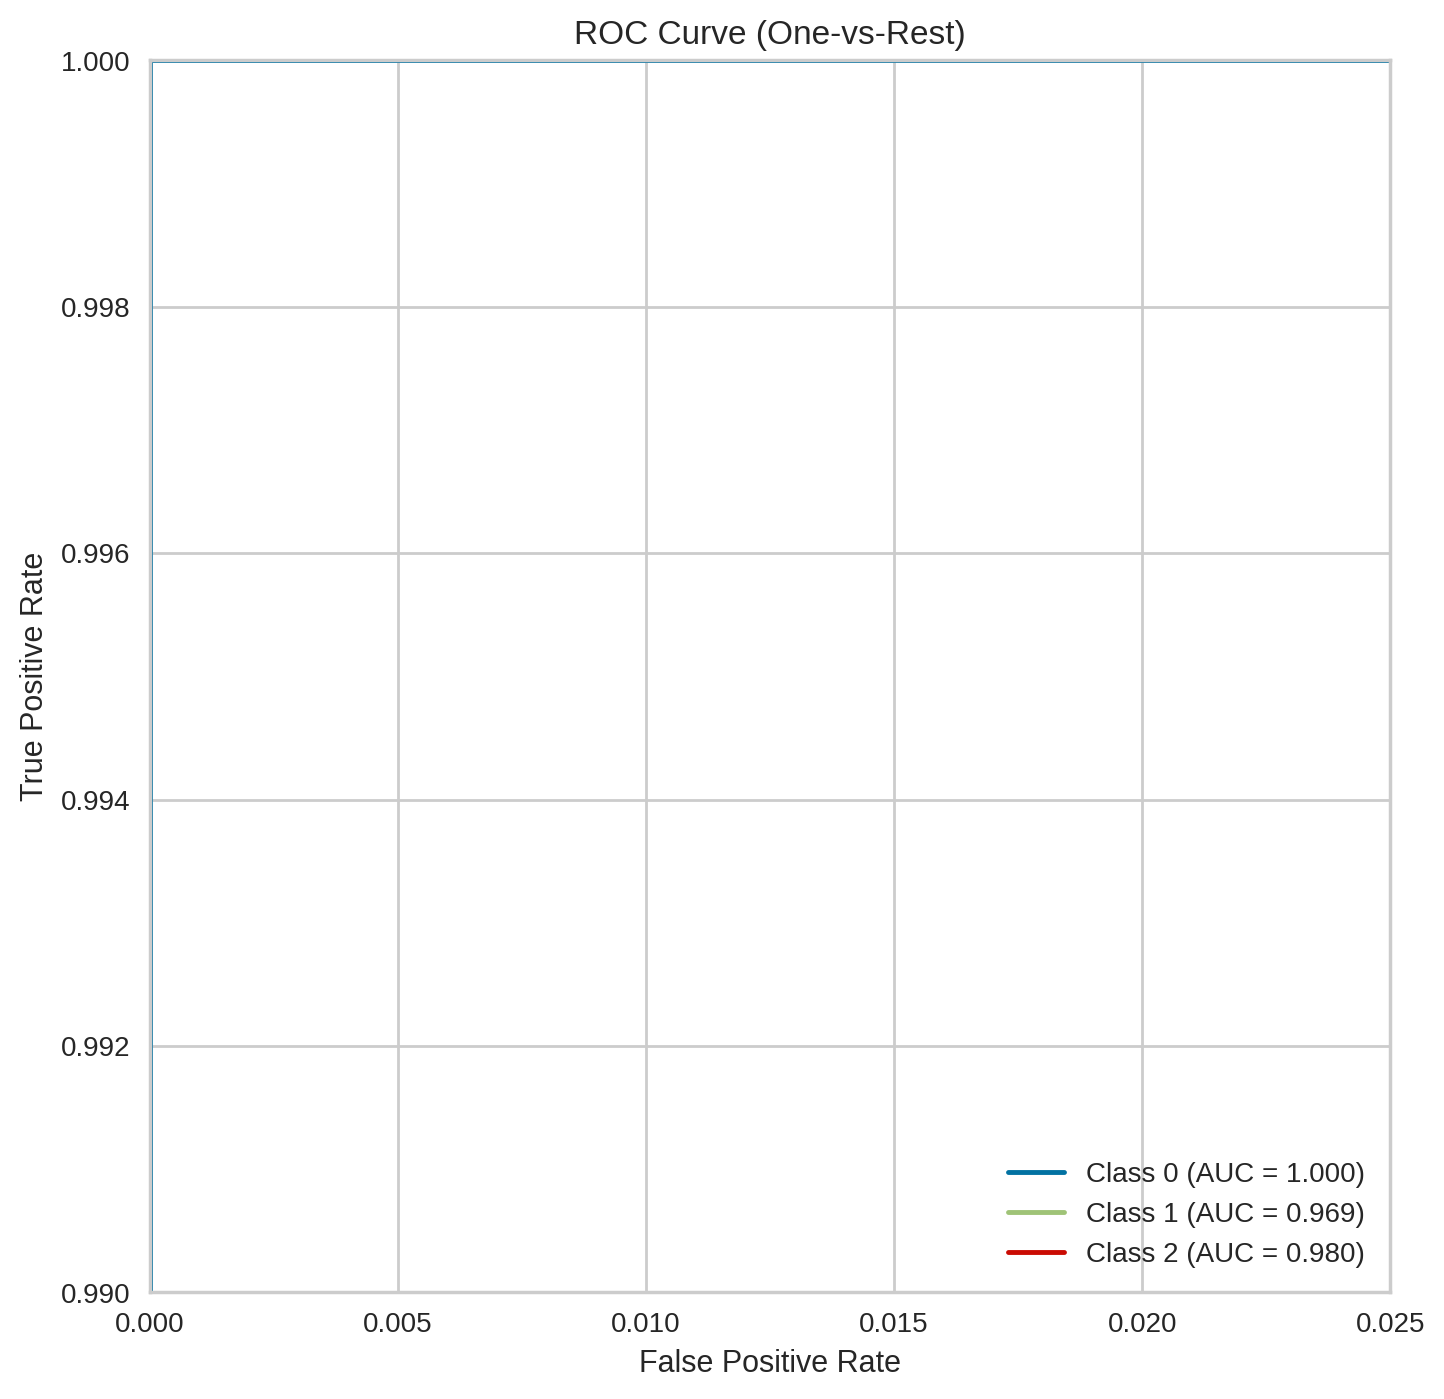

In [ ]:
# ROC Curve (Binary or One‑vs‑Rest) with Zoom-in on High Performance

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

X_test, y_test = experiment.test_numpy()
y_score = sk_model.predict_proba(X_test)

classes = np.unique(y_test)
n_classes = len(classes)

plt.figure(figsize=(8, 8), dpi=200)

# Binary classification
if n_classes == 2:
    # Use probability of positive class
    y_score_bin = y_score[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score_bin)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                    estimator_name='Binary classifier').plot()

# Multiclass classification
else:
    # Binarize labels (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=classes)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

    plt.legend(loc="lower right")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest)")

# Zoom
plt.xlim([0.0, 0.025])
plt.ylim([0.99, 1.0])
plt.grid(True)

plt.show()